In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

In [3]:
def collect_channels(filepath, samplingrate, offset, duration_in_secs):
    channels = [[], [], [], [], [], [], [], []]

    with open(filepath, "rb") as rawFile:

        rawFile.seek(int(2*8*samplingrate*offset), 0)
        for i in range(samplingrate*duration_in_secs):
            for j in range(8):
                bytes = rawFile.read(2)
                sample_int = int.from_bytes(bytes = bytes, byteorder = "little", signed = True)
                sample_float = sample_int * (5 / 32768)

                channels[j].append(sample_float)

    return np.array(channels)

In [4]:
def plot_audio_seg_spec(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

def plot_audio_seg_signal(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Signal of {audio_features['plot_title']}", fontsize=24)
    plt.plot(audio_seg)
    plot_xtype = 'float'
    plt.xlim(0, duration*fs)
    plt.ylim(-3.5, 3.5)
    plt.grid(which='both')
    plt.xticks(ticks=np.linspace(0, audio_features['duration']*fs, 11), 
                labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_seg_fft(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"FFT of {audio_features['plot_title']}", fontsize=24)
    abs_sig = np.abs(scipy.fft.rfft(audio_seg, n=len(audio_seg)))
    abs_sig = abs_sig / len(abs_sig)
    plt.plot(20*np.log10(abs_sig/np.max(abs_sig)))
    plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, len(abs_sig), 11), 
                labels=np.round(np.linspace(0, (fs/2), 11, dtype=plot_xtype), 2)/1e3, rotation=30)
    plt.ylabel("Voltage (dB)")
    plt.xlabel("Frequency (kHz)")
    plt.grid(which='both')
    plt.show()
    
FREQ_COLORS = {'LF':'cyan',
               'HF':'orange'}

def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

In [5]:
fs = 250000
file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
filepath = file_dir / 'hour_0.raw'

In [6]:
cfg = get_config()
cfg['tmp_dir'] = Path('../output/tmp')
cfg['run_model'] = True
cfg['should_csv'] = True
cfg['save'] = True

In [7]:
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = abs(20 * np.log10(signal_power_rms / noise_power_rms))

    return snr

def bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    high_cutoff =  (high_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, [low_cutoff, high_cutoff], btype='band', analog=False)
    band_limited_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return band_limited_audio_seg

def highpass_audio_signal(audio_seg, fs, low_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, low_cutoff, btype='high', analog=False)
    high_passed_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return high_passed_audio_seg

def compute_welch_psd_of_call(call, fs, audio_info):
    freqs, welch = scipy.signal.welch(call, fs=fs, detrend=False, scaling='spectrum')
    cropped_welch = welch[(freqs<=audio_info['max_freq_visible'])]
    audio_spectrum_mag = np.abs(cropped_welch)
    audio_spectrum_db =  10*np.log10(audio_spectrum_mag)
    normalized_audio_spectrum_db = audio_spectrum_db - audio_spectrum_db.max()

    thresh = -100
    peak_db = np.zeros(len(normalized_audio_spectrum_db))+thresh
    peak_db[normalized_audio_spectrum_db>=thresh] = normalized_audio_spectrum_db[normalized_audio_spectrum_db>=thresh]

    original_freq_vector = np.arange(0, len(peak_db), 1).astype('int')
    common_freq_vector = np.linspace(0, len(peak_db)-1, audio_info['num_points']).astype('int')
    interp_kind = 'linear'
    interpolated_points_from_welch = scipy.interpolate.interp1d(original_freq_vector, peak_db, kind=interp_kind)(common_freq_vector)

    return interpolated_points_from_welch

def gather_features_of_interest(dets, kmean_welch, audio_file):
    fs = audio_file.samplerate
    features_of_interest = dict()
    features_of_interest['call_signals'] = []
    features_of_interest['welch_signals'] = []
    features_of_interest['snrs'] = []
    features_of_interest['peak_freqs'] = []
    features_of_interest['classes'] = []
    nyquist = fs//2
    for index, row in dets.iterrows():
        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)
        
        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]
        features_of_interest['call_signals'].append(snr_call_signal)

        high_passed_audio_seg = highpass_audio_signal(audio_seg, fs, 15000)
        snr_mod_signal = high_passed_audio_seg.copy()
        snr_mod_signal[:int(fs*(length_of_section))] = 0
        snr_mod_noise = high_passed_audio_seg - snr_mod_signal
        snr_mod_call_signal = snr_mod_signal[-int(fs*length_of_section):]
        snr_mod_noise_signal = snr_mod_noise[:int(fs*length_of_section)]
        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_mod_call_signal, snr_mod_noise_signal)
        features_of_interest['snrs'].append(snr)

        welch_info = dict()
        welch_info['num_points'] = 100
        max_visible_frequency = 96000
        welch_info['max_freq_visible'] = max_visible_frequency
        welch_signal = compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
        features_of_interest['welch_signals'].append(welch_signal)

        peaks = np.where(welch_signal==max(welch_signal))[0][0]
        features_of_interest['peak_freqs'].append((max_visible_frequency/len(welch_signal))*peaks)
        
        welch_signal = (welch_signal).reshape(1, len(welch_signal))
        features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

    features_of_interest['call_signals'] = np.array(features_of_interest['call_signals'], dtype='object')

    return features_of_interest

def open_and_get_call_info(audio_file, dets):
    welch_key = 'all_locations'
    output_dir = Path(f'/Users/adityakrishna/duty-cycle-investigation/data/generated_welch/{welch_key}')
    output_file_type = 'top1_inbouts_welch_signals'
    welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
    k = 2
    kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)

    features_of_interest = gather_features_of_interest(dets, kmean_welch, audio_file)

    dets.reset_index(drop=True, inplace=True)

    dets['sampling_rate'] = len(dets) * [audio_file.samplerate]
    dets.insert(0, 'SNR', features_of_interest['snrs'])
    dets.insert(0, 'peak_frequency', features_of_interest['peak_freqs'])
    dets.insert(0, 'KMEANS_CLASSES', pd.Series(features_of_interest['classes']).map(LABEL_FOR_GROUPS))

    return features_of_interest['call_signals'], dets

def classify_calls_from_file(bd2_predictions, data_params):
    file_path = Path(data_params['audio_file'])
    audio_file = sf.SoundFile(file_path)
    call_signals, dets = open_and_get_call_info(audio_file, bd2_predictions.copy())
    return dets

def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_preds_classed = classify_calls_from_file(bd_annotations_df, cur_seg['audio_seg'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_preds_classed,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])

    median_peak_HF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='HF']['peak_frequency'].median()
    median_peak_LF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='LF']['peak_frequency'].median()
    print(f'Median LF frequency in File: {median_peak_LF_freq}')
    print(f'Median HF frequency in File: {median_peak_HF_freq}')
    lf_inds = (bd_dets['peak_frequency']<median_peak_LF_freq+7000)&(bd_dets['peak_frequency']>median_peak_LF_freq-7000)
    hf_inds = (bd_dets['peak_frequency']>median_peak_HF_freq-7000)

    lf_dets = bd_dets[lf_inds&(bd_dets['KMEANS_CLASSES']=='LF')]
    hf_dets = bd_dets[hf_inds&(bd_dets['KMEANS_CLASSES']=='HF')]

    all_dets = pd.concat([hf_dets, lf_dets]).sort_index()
    return all_dets

In [8]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    if (cfg['run_model']):
        cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
        filepath = (cfg['output_dir'] / f'{cfg["csv_filename"]}.csv')
        if not(filepath.is_file()):
            print(f'Generating detections from {file}')
            segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
            file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
            bd_preds = run_models(file_path_mappings)
            if cfg['save']:
                batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
            batdetect2_pipeline.delete_segments(segmented_file_paths)
        else:
            bd_preds = pd.read_csv(filepath)

    return bd_preds

In [9]:
%matplotlib inline 

C = 343 # m/s speed of sound in air
offset = 1440
num_channels = 8
duration_in_secs = 120
channel_dets = pd.DataFrame()
num_good_channels = num_channels - 1
num_nonref_channels = num_good_channels - 1
write_dir = Path(f'/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/{filepath.stem}_{int(offset)}to{int(offset+duration_in_secs)}')

for selected_channel in np.arange(0, num_channels).astype(int):
    if selected_channel!=1:
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        cfg['output_dir'] = write_dir
        cfg['input_audio'] = Path(write_file)
        dets = run_pipeline_on_file(write_file, cfg)
        plot_dets = dets.copy()
        plot_dets['start_time'] += offset
        plot_dets['end_time'] += offset
        channel_dets = pd.concat([channel_dets, plot_dets])

Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV


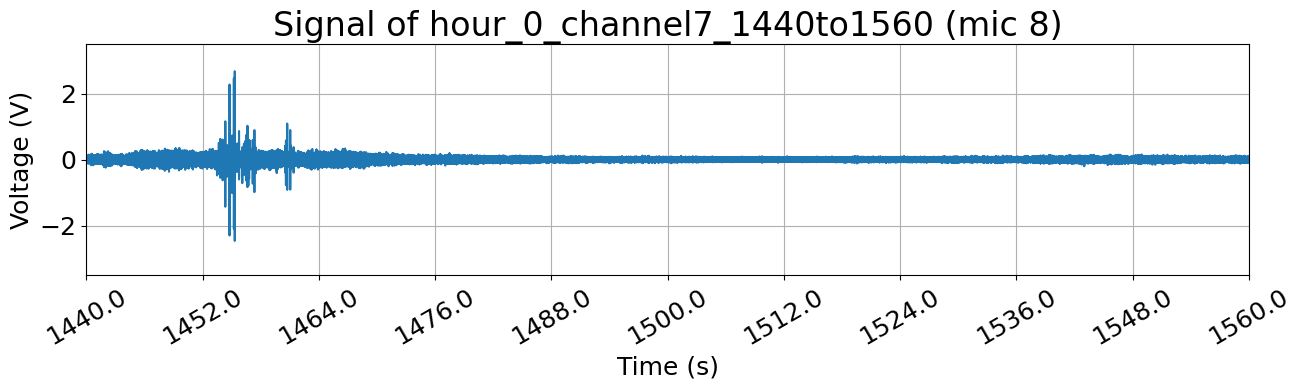

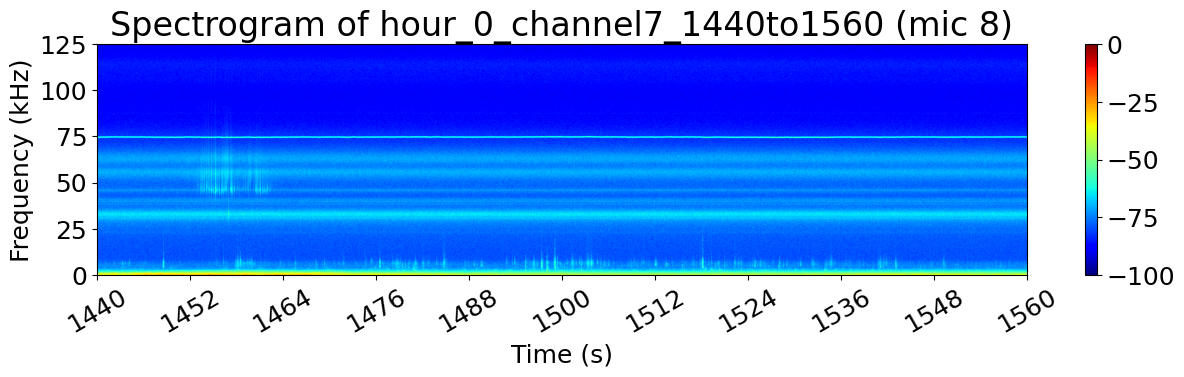

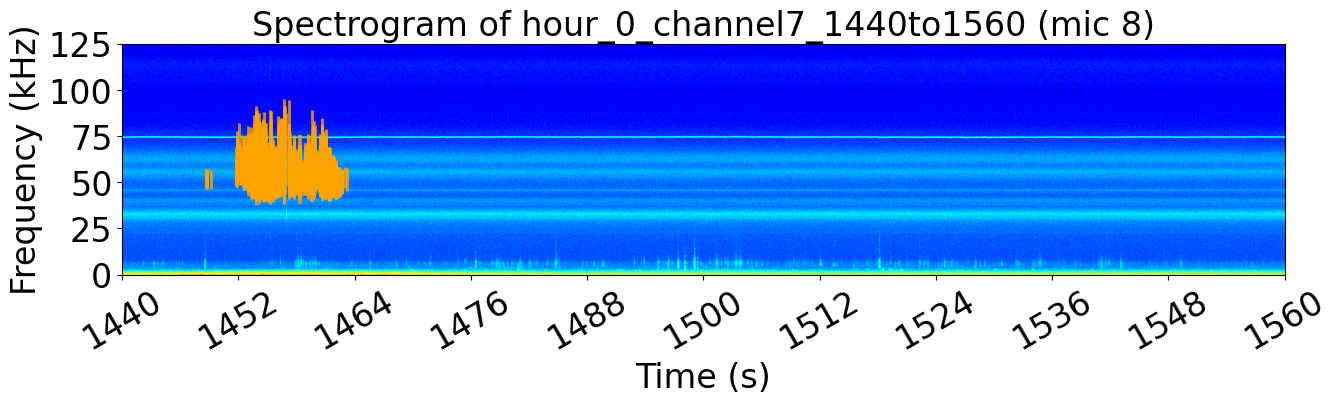

In [10]:
selected_channel = 7
write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
    
cfg['output_dir'] = write_dir
cfg['input_audio'] = Path(write_file)

recorded_audio = sf.SoundFile(write_file)
audio_seg = recorded_audio.read(int(fs*duration_in_secs))

print(f'Plotting data from {write_file}')
vmax = 0
vmin = -100

audio_features = dict()
audio_features['figsize'] = (15, 3)
audio_features['file_path'] = write_file
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = offset
audio_features['duration'] = duration_in_secs

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
plot_audio_seg_signal(audio_features)
plot_audio_seg_spec(audio_features, spec_features)
plot_colored_dets_over_audio(audio_features, spec_features, channel_dets)

In [11]:
channel_dets = channel_dets.sort_values(by='start_time').copy()
channel_dets.reset_index(drop=True, inplace=True)
channel_dets

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,48000.0,0.068571,1448.6975,1448.7026,46093.0,56984.0,Pipistrellus pipistrellus,0.548,0.575,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,54720.0,1.593416,1448.7005,1448.7067,46093.0,55914.0,Pipistrellus pipistrellus,0.535,0.565,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,54720.0,0.356942,1448.7845,1448.7892,46953.0,57160.0,Pipistrellus pipistrellus,0.507,0.543,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,48000.0,0.412240,1448.7865,1448.7918,46953.0,55979.0,Pipistrellus pipistrellus,0.596,0.608,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,48000.0,0.799621,1448.7865,1448.7921,47812.0,53619.0,Pipistrellus pipistrellus,0.531,0.601,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,HF,48960.0,7.334427,1462.6615,1462.6661,44375.0,57368.0,Pipistrellus pipistrellus,0.454,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
434,HF,48960.0,6.469781,1462.6615,1462.6661,43515.0,56861.0,Pipistrellus pipistrellus,0.375,0.546,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
435,HF,48960.0,4.529781,1462.6645,1462.6694,46093.0,56495.0,Pipistrellus pipistrellus,0.576,0.602,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
436,HF,53760.0,0.276119,1463.0075,1463.0117,46953.0,58192.0,Pipistrellus pipistrellus,0.401,0.503,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


In [12]:
def remove_close_times(df, time_column, threshold = 0.01):
    # Sort DataFrame by the time column
    df_sorted = df.sort_values(by=time_column).reset_index(drop=True)
    
    # Create a list to store the indices of the rows to keep
    filtered_indices = [0]  # Always keep the first row after sorting
    
    # Iterate through the sorted DataFrame, comparing each time to the previous kept time
    for i in range(1, len(df_sorted)):
        # Check if the difference between consecutive times is greater than or equal to the threshold
        if (df_sorted.loc[i, time_column] - df_sorted.loc[filtered_indices[-1], time_column]) >= threshold:
            filtered_indices.append(i)  # Keep the row if it meets the threshold
    
    # Return a DataFrame with only the filtered rows
    return df_sorted.loc[filtered_indices].reset_index(drop=True)

In [13]:
filtered_df = remove_close_times(channel_dets, 'start_time')
removed_overlaps = remove_close_times(filtered_df, 'end_time')
removed_overlaps

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,48000.0,0.068571,1448.6975,1448.7026,46093.0,56984.0,Pipistrellus pipistrellus,0.548,0.575,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,54720.0,0.356942,1448.7845,1448.7892,46953.0,57160.0,Pipistrellus pipistrellus,0.507,0.543,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,52800.0,1.259528,1449.1555,1449.1599,46093.0,56543.0,Pipistrellus pipistrellus,0.478,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,56640.0,3.075944,1451.7465,1451.7495,49531.0,69124.0,Myotis alcathoe,0.338,0.505,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,56640.0,5.651969,1451.8055,1451.8087,50390.0,74128.0,Myotis alcathoe,0.407,0.568,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,HF,47040.0,9.455383,1462.3895,1462.3942,43515.0,56780.0,Pipistrellus pipistrellus,0.524,0.639,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
101,HF,47040.0,8.727689,1462.4765,1462.4814,42656.0,56720.0,Pipistrellus pipistrellus,0.447,0.596,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
102,HF,48960.0,7.334427,1462.6615,1462.6661,44375.0,57368.0,Pipistrellus pipistrellus,0.454,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
103,HF,53760.0,0.276119,1463.0075,1463.0117,46953.0,58192.0,Pipistrellus pipistrellus,0.401,0.503,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_1440to1560/hour_0_channel7_1440to1560.WAV


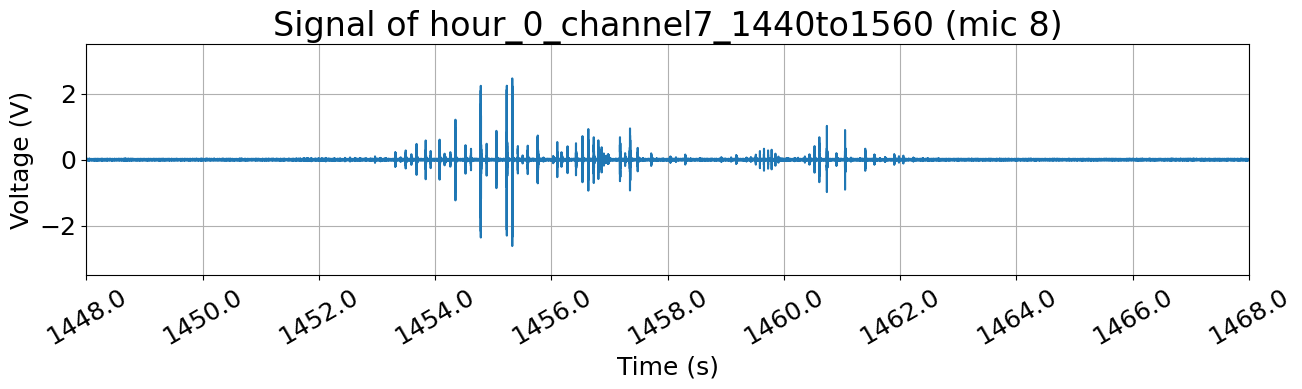

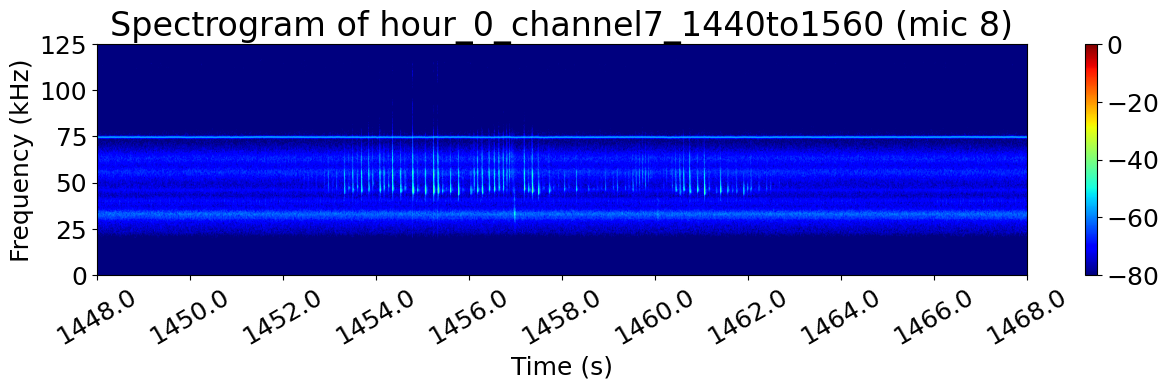

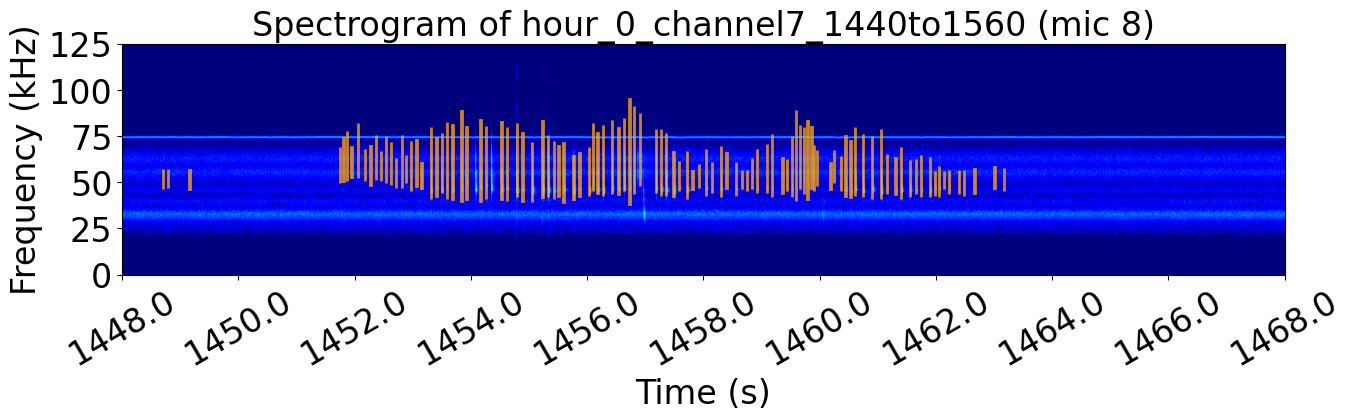

In [14]:
%matplotlib inline

selected_channel = 7
write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
    
cfg['output_dir'] = write_dir
cfg['input_audio'] = Path(write_file)

recorded_audio = sf.SoundFile(write_file)
start = 8
length = 20
recorded_audio.seek(int(fs*start))
audio_seg = recorded_audio.read(int(fs*length))
highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, 20000)

print(f'Plotting data from {write_file}')
vmax = 0
vmin = -80

audio_features = dict()
audio_features['figsize'] = (15, 3)
audio_features['file_path'] = write_file
audio_features['audio_seg'] = highpassed_audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = offset + start
audio_features['duration'] = length

spec_features = dict()
spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
plot_audio_seg_signal(audio_features)
plot_audio_seg_spec(audio_features, spec_features)
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(offset+start))&(removed_overlaps['end_time']<=(offset+start+length))]
subset = plot_dets[plot_dets['SNR']>20].reset_index(drop=True)
plot_colored_dets_over_audio(audio_features, spec_features, plot_dets)

In [15]:
subset

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,46080.0,26.711160,1453.6805,1453.6859,40937.0,81003.0,Pipistrellus pipistrellus,0.337,0.508,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
1,HF,47040.0,27.644604,1453.8375,1453.8436,40078.0,88766.0,Myotis alcathoe,0.434,0.560,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
2,HF,48000.0,22.325381,1454.1625,1454.1686,40078.0,83916.0,Pipistrellus pipistrellus,0.378,0.596,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
3,HF,48000.0,20.410957,1454.2605,1454.2666,40937.0,80201.0,Pipistrellus pipistrellus,0.405,0.605,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
4,HF,46080.0,26.647709,1454.5205,1454.5275,40937.0,82408.0,Pipistrellus pipistrellus,0.435,0.534,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
5,HF,47040.0,21.339820,1454.6155,1454.6220,40078.0,80001.0,Pipistrellus pipistrellus,0.293,0.562,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
6,HF,45120.0,35.068233,1454.7845,1454.7922,41796.0,82143.0,Pipistrellus pipistrellus,0.481,0.538,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
7,HF,46080.0,23.863377,1454.8845,1454.8907,40078.0,76349.0,Pipistrellus pipistrellus,0.382,0.520,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
8,HF,46080.0,33.357139,1455.0525,1455.0586,39218.0,71717.0,Pipistrellus pipistrellus,0.389,0.538,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...
9,HF,46080.0,40.438035,1455.2315,1455.2383,41796.0,82898.0,Pipistrellus pipistrellus,0.426,0.511,-1,Echolocation,250000.0,/Volumes/Elements/UBNA_array_tests/mic_array_t...


In [158]:
microphones_used = np.array([1, 3, 4, 5, 6, 7, 8])
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

In [174]:
def get_approx_call_dur(det):
    det_dur = (det['end_time'] - det['start_time'])
    return det_dur/3

def extract_bandpassed_detection_from_wavfilepath(wav_filepath, start, length, det):
    recorded_audio = sf.SoundFile(wav_filepath)
    fs = recorded_audio.samplerate
    recorded_audio.seek(int(fs*start))
    audio_seg = recorded_audio.read(int(fs*length))
    bandpassed_audio_seg = bandpass_audio_signal(audio_seg, fs, det['low_freq'], det['high_freq'])
    return bandpassed_audio_seg

def extract_approx_call_start_for_snr_calcs(bandpassed_det, approx_call_dur):
    p_energy_cumsum = np.cumsum((bandpassed_det)**2)/np.sum(bandpassed_det**2)
    cumsum_start = np.where(p_energy_cumsum>0.1)[0][0]
    found_call_dur = int(fs*(approx_call_dur+0.004))
    found_call_start = cumsum_start-int(fs*0.003)
    return found_call_start, found_call_dur

def extract_approx_call_windows_for_snr_calcs(bandpassed_det, call_start, call_dur):
    call_end = (call_start+call_dur)
    found_call = bandpassed_det[call_start:call_end]
    found_echo = bandpassed_det[call_end+int(fs*0.002):]
    found_background = bandpassed_det[max(0, call_start-call_dur):call_start]
    return found_call, found_background, found_echo

def snr_quality_metric(snrcb, snreb, snrce):
    return (snrcb)/snrce

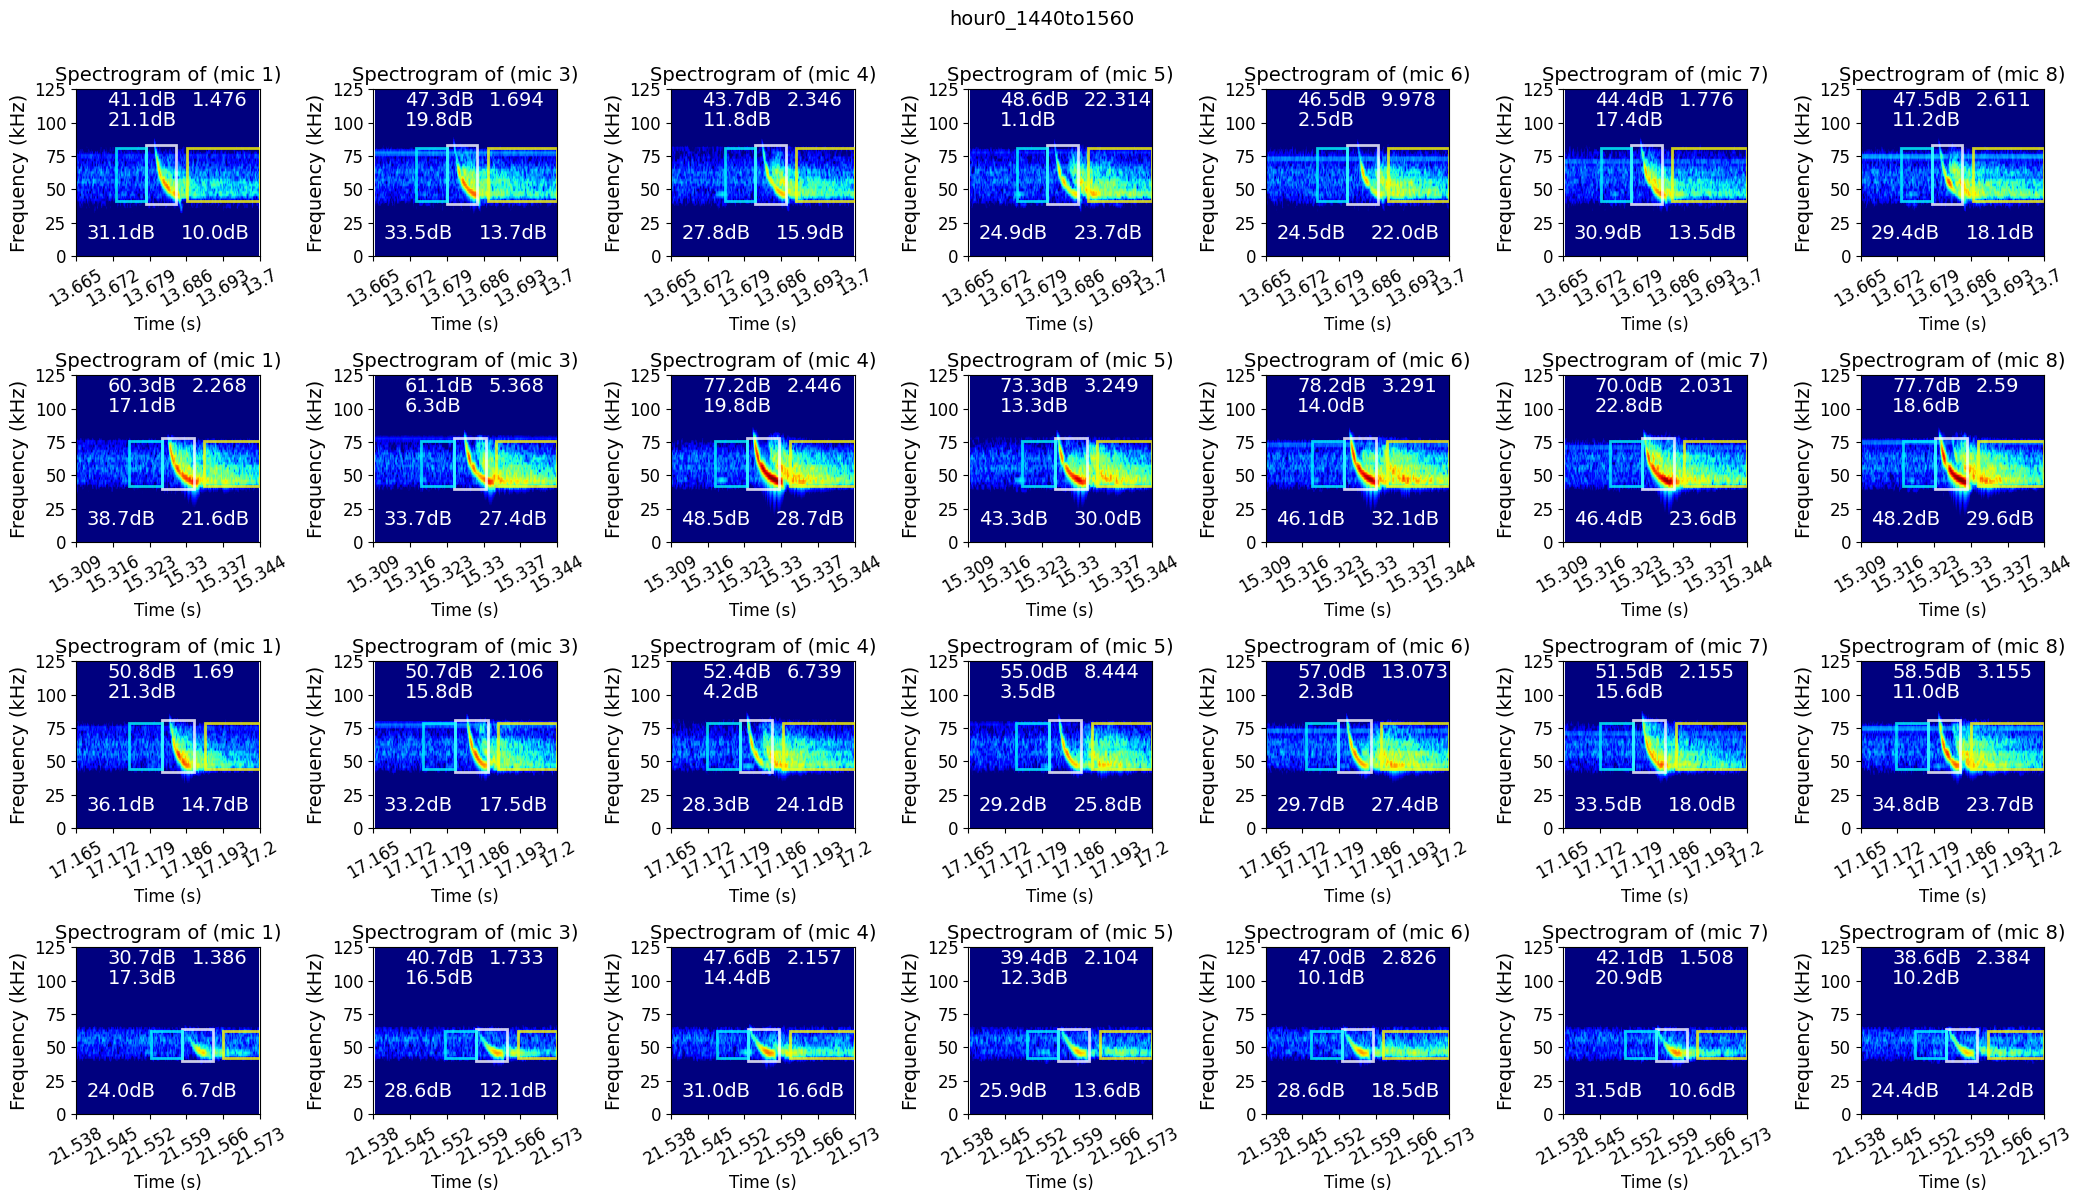

In [175]:
%matplotlib inline

example_calls = []
example_call_snrs = []
example_snr_facs = []
example_det_durs = []
channel_num = 0
examining_df = subset[::10].copy()
plt.figure(figsize=(3*num_good_channels, 3*len(examining_df)))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=14)
for i, det in examining_df.iterrows():
    start = det['start_time'] - offset - 0.015
    length = 0.035
    approx_call_dur = get_approx_call_dur(det)
    example_det_durs += [approx_call_dur]

    for selected_channel in (np.arange(0, num_channels).astype(int)):
        if selected_channel in (microphones_used-1):
            write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
            channel_num+=1
            
            bandpassed_det = extract_bandpassed_detection_from_wavfilepath(write_file, start, length, det)
            example_calls += [bandpassed_det]

            found_call_start, found_call_dur = extract_approx_call_start_for_snr_calcs(bandpassed_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            found_call, found_background, found_echo = extract_approx_call_windows_for_snr_calcs(bandpassed_det, 
                                                                                                 found_call_start, 
                                                                                                 found_call_dur)
            snrce = get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = get_snr_from_band_limited_signal(found_call, found_background)
            snreb = get_snr_from_band_limited_signal(found_echo, found_background)
            example_call_snrs += [snrcb + snreb]
            example_snr_facs += [snr_quality_metric(snrcb, snreb, snrce)]

            spec_features = dict()
            spec_features['NFFT'] = 132 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
            spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
            spec_features['vmin'] = -80
            spec_features['vmax'] = 0

            plt.subplot(len(examining_df), num_good_channels, channel_num)
            plt.rcParams.update({'font.size': 12})
            plt.title(f"Spectrogram of (mic {selected_channel+1})", fontsize=14)
            plt.specgram(bandpassed_det+1e-6, NFFT=spec_features['NFFT'], 
                         cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
            plt.text(x=int(fs*0.003),y=0.9,s=f'{round(example_call_snrs[-1], 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.003),y=0.78,s=f'{round(snrce, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.001),y=0.1,s=f'{round(snrcb, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.01),y=0.1,s=f'{round(snreb, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.011),y=0.9,s=f'{round(example_snr_facs[-1], 3)}',color='w',fontsize=14)
            ax = plt.gca()
            rect_call = patches.Rectangle((found_call_start/2, (det['low_freq']-2000)/(fs/2)), 
                            found_call_dur/2, ((det['high_freq']-det['low_freq'])+4000)/(fs/2), 
                            linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
            ax.add_patch(rect_call)
            rect_echo = patches.Rectangle(((found_call_end+int(fs*0.002))/2, det['low_freq']/(fs/2)), 
                            ((fs*length) - (found_call_end+int(fs*0.002)))/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
            ax.add_patch(rect_echo)
            rect_background = patches.Rectangle(((found_call_start-found_call_dur)/2, det['low_freq']/(fs/2)), 
                            (found_call_dur)/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
            ax.add_patch(rect_background)
            plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
            plt.xticks(ticks=np.linspace(0, length*(fs/2), 6), labels=np.round(np.linspace(start, start+length, 6, dtype=float), 3), rotation=30)
            plt.xlabel("Time (s)")    

plt.tight_layout()
plt.show()

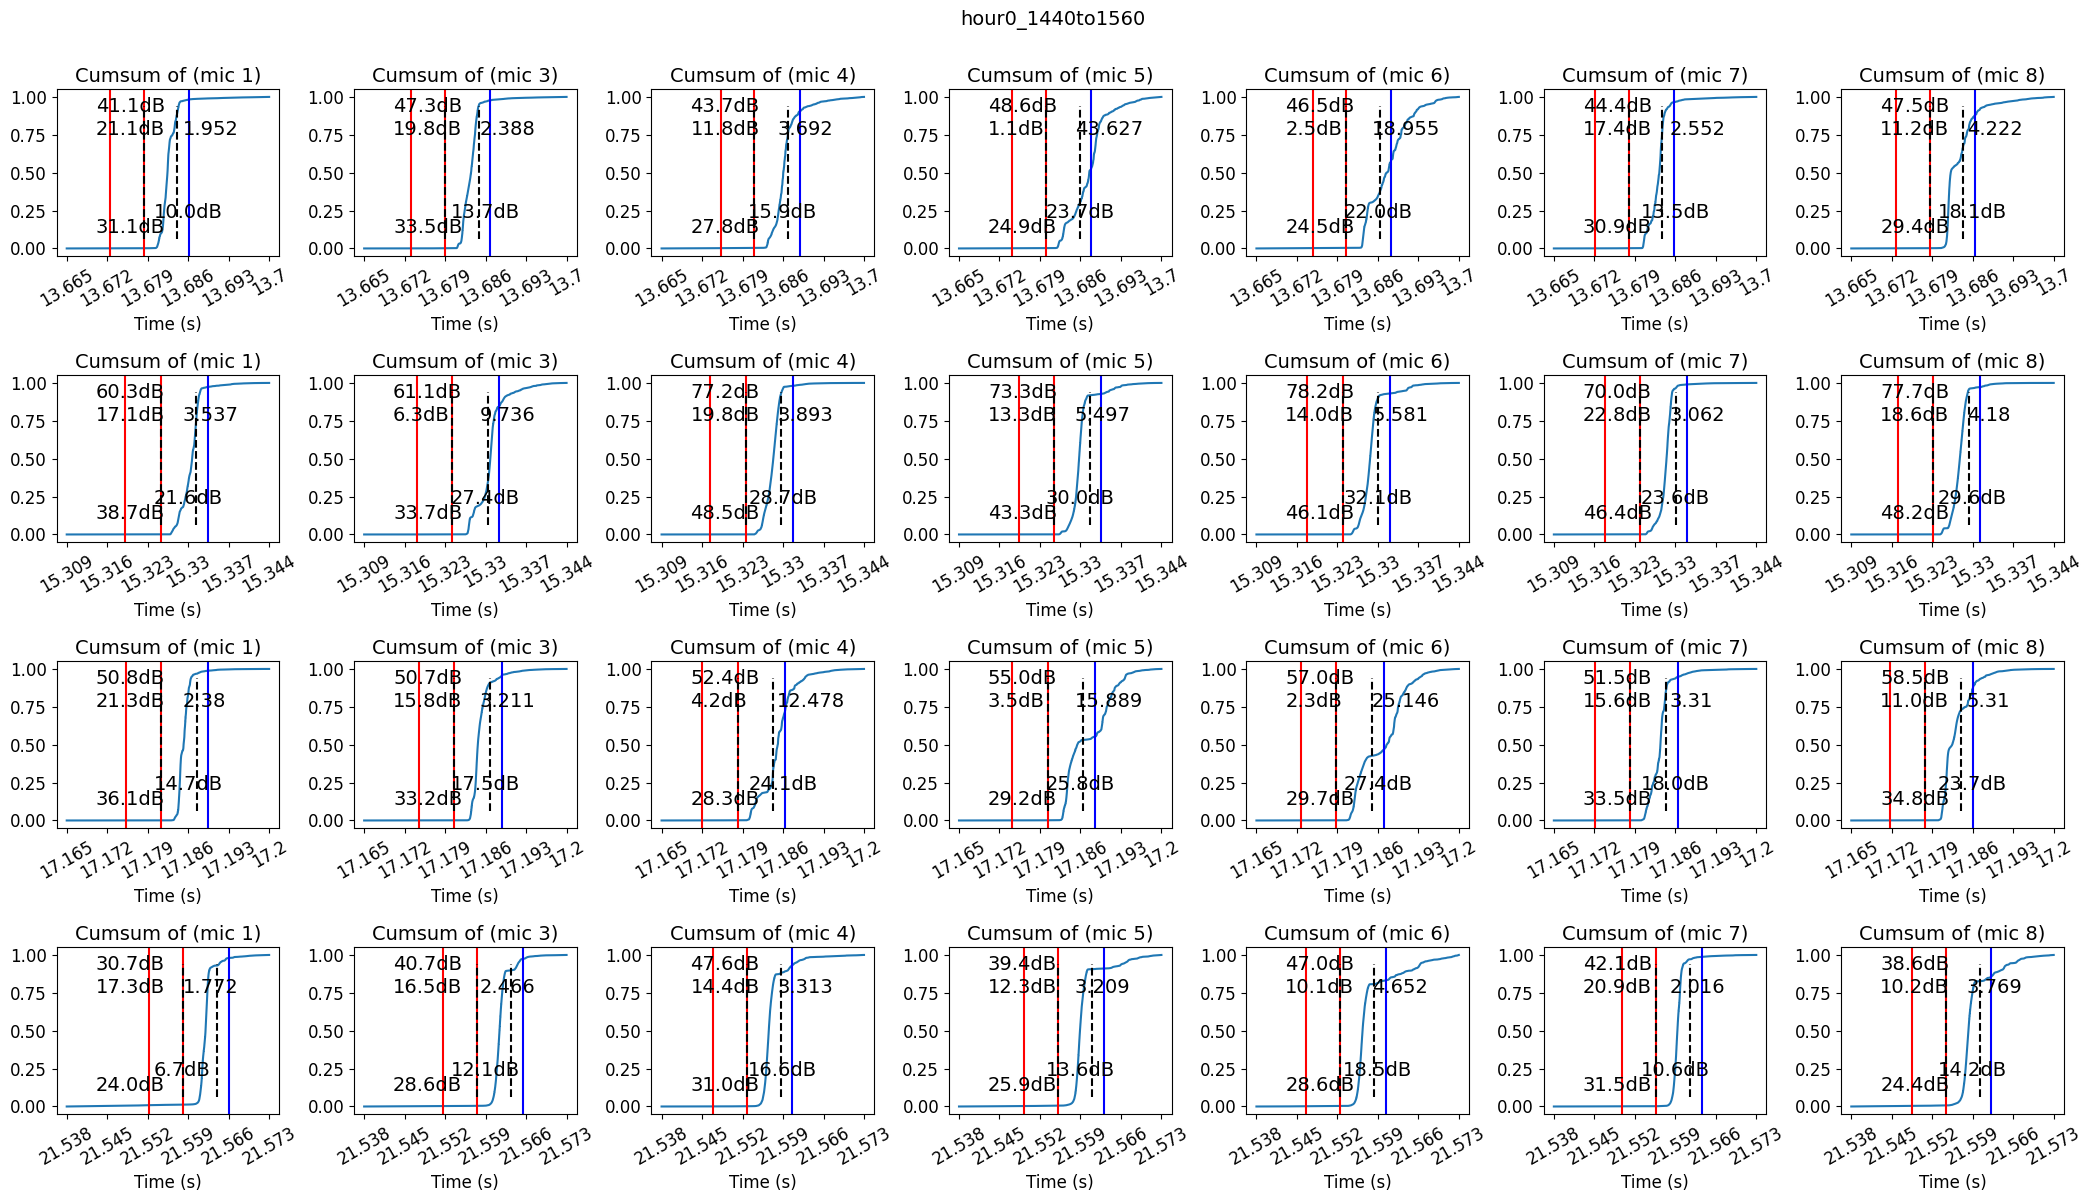

In [176]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(3*num_good_channels, 3*len(examining_df)))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=14)
for i, det in examining_df.iterrows():
    start = det['start_time'] - offset - 0.015
    length = 0.035
    approx_call_dur = get_approx_call_dur(det)
    for selected_channel in (np.arange(0, num_channels).astype(int)):
        if selected_channel in (microphones_used-1):
            write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
            channel_num+=1
            
            bandpassed_det = extract_bandpassed_detection_from_wavfilepath(write_file, start, length, det)
            p_energy_cumsum = np.cumsum((bandpassed_det)**2)/np.sum(bandpassed_det**2)
            found_call_start, found_call_dur = extract_approx_call_start_for_snr_calcs(bandpassed_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            found_call, found_background, found_echo = extract_approx_call_windows_for_snr_calcs(bandpassed_det, 
                                                                                                 found_call_start, 
                                                                                                 found_call_dur)
            snrce = get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = get_snr_from_band_limited_signal(found_call, found_background)
            snreb = get_snr_from_band_limited_signal(found_echo, found_background)

            plt.subplot(len(examining_df), num_good_channels, channel_num)
            plt.rcParams.update({'font.size': 12})
            plt.title(f"Cumsum of (mic {selected_channel+1})", fontsize=14)
            plt.plot(p_energy_cumsum)
            plt.axvline(x=found_call_start-found_call_dur, color='red')
            plt.axvline(x=found_call_start, color='red')
            plt.axvline(x=found_call_end+int(fs*0.002), color='blue')
            plt.axvline(x=found_call_start, color='k', linestyle='dashed', ymin=0.1, ymax=0.9)
            plt.axvline(x=found_call_end, color='k', linestyle='dashed', ymin=0.1, ymax=0.9)
            plt.text(x=int(fs*0.005),y=0.9,s=f'{round(snrcb+snreb, 1)}dB',color='k',fontsize=14)
            plt.text(x=int(fs*0.005),y=0.75,s=f'{round(snrce, 1)}dB',color='k',fontsize=14)
            plt.text(x=int(fs*0.005),y=0.1,s=f'{round(snrcb, 1)}dB',color='k',fontsize=14)
            plt.text(x=int(fs*0.015),y=0.2,s=f'{round(snreb, 1)}dB',color='k',fontsize=14)
            plt.text(x=int(fs*0.02),y=0.75,s=f'{round((snrcb+snreb)/snrce, 3)}',color='k',fontsize=14)
            plt.xticks(ticks=np.linspace(0, length*(fs), 6), labels=np.round(np.linspace(start, start+length, 6, dtype=float), 3), rotation=30)
            plt.xlabel("Time (s)")    

plt.tight_layout()
plt.show()

In [177]:
example_calls = np.array(example_calls).reshape((len(examining_df), num_good_channels, int(fs*length)))
example_call_snrs = np.array(example_call_snrs).reshape((len(examining_df), num_good_channels))
example_snr_facs = np.array(example_snr_facs).reshape((len(examining_df), num_good_channels))
example_det_durs = np.array(example_det_durs)

In [178]:
def extract_call_starts_for_ref_call(ref_call_segment, approx_call_dur):
    p_energy_cumsum = np.cumsum((ref_call_segment)**2)/np.sum(ref_call_segment**2)
    cumsum_start = np.where(p_energy_cumsum>0.1)[0][0]
    found_call_dur = int(fs*(approx_call_dur+0.004))
    found_call_start = cumsum_start-int(fs*0.003)
    return found_call_start, found_call_dur

def extract_reference_call_only(ref_call_segment, approx_call_dur):
    found_call_start, found_call_dur = extract_call_starts_for_ref_call(ref_call_segment, approx_call_dur)
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only

def generalized_cross_correlation_to_find_t_delay(signal1, signal2):
    correlation = signal.correlate(signal1, signal2, mode='full')
    lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')
    max_lag_index = np.argmax(correlation)
    time_delay_in_samples = lags[max_lag_index]
    return time_delay_in_samples

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:]

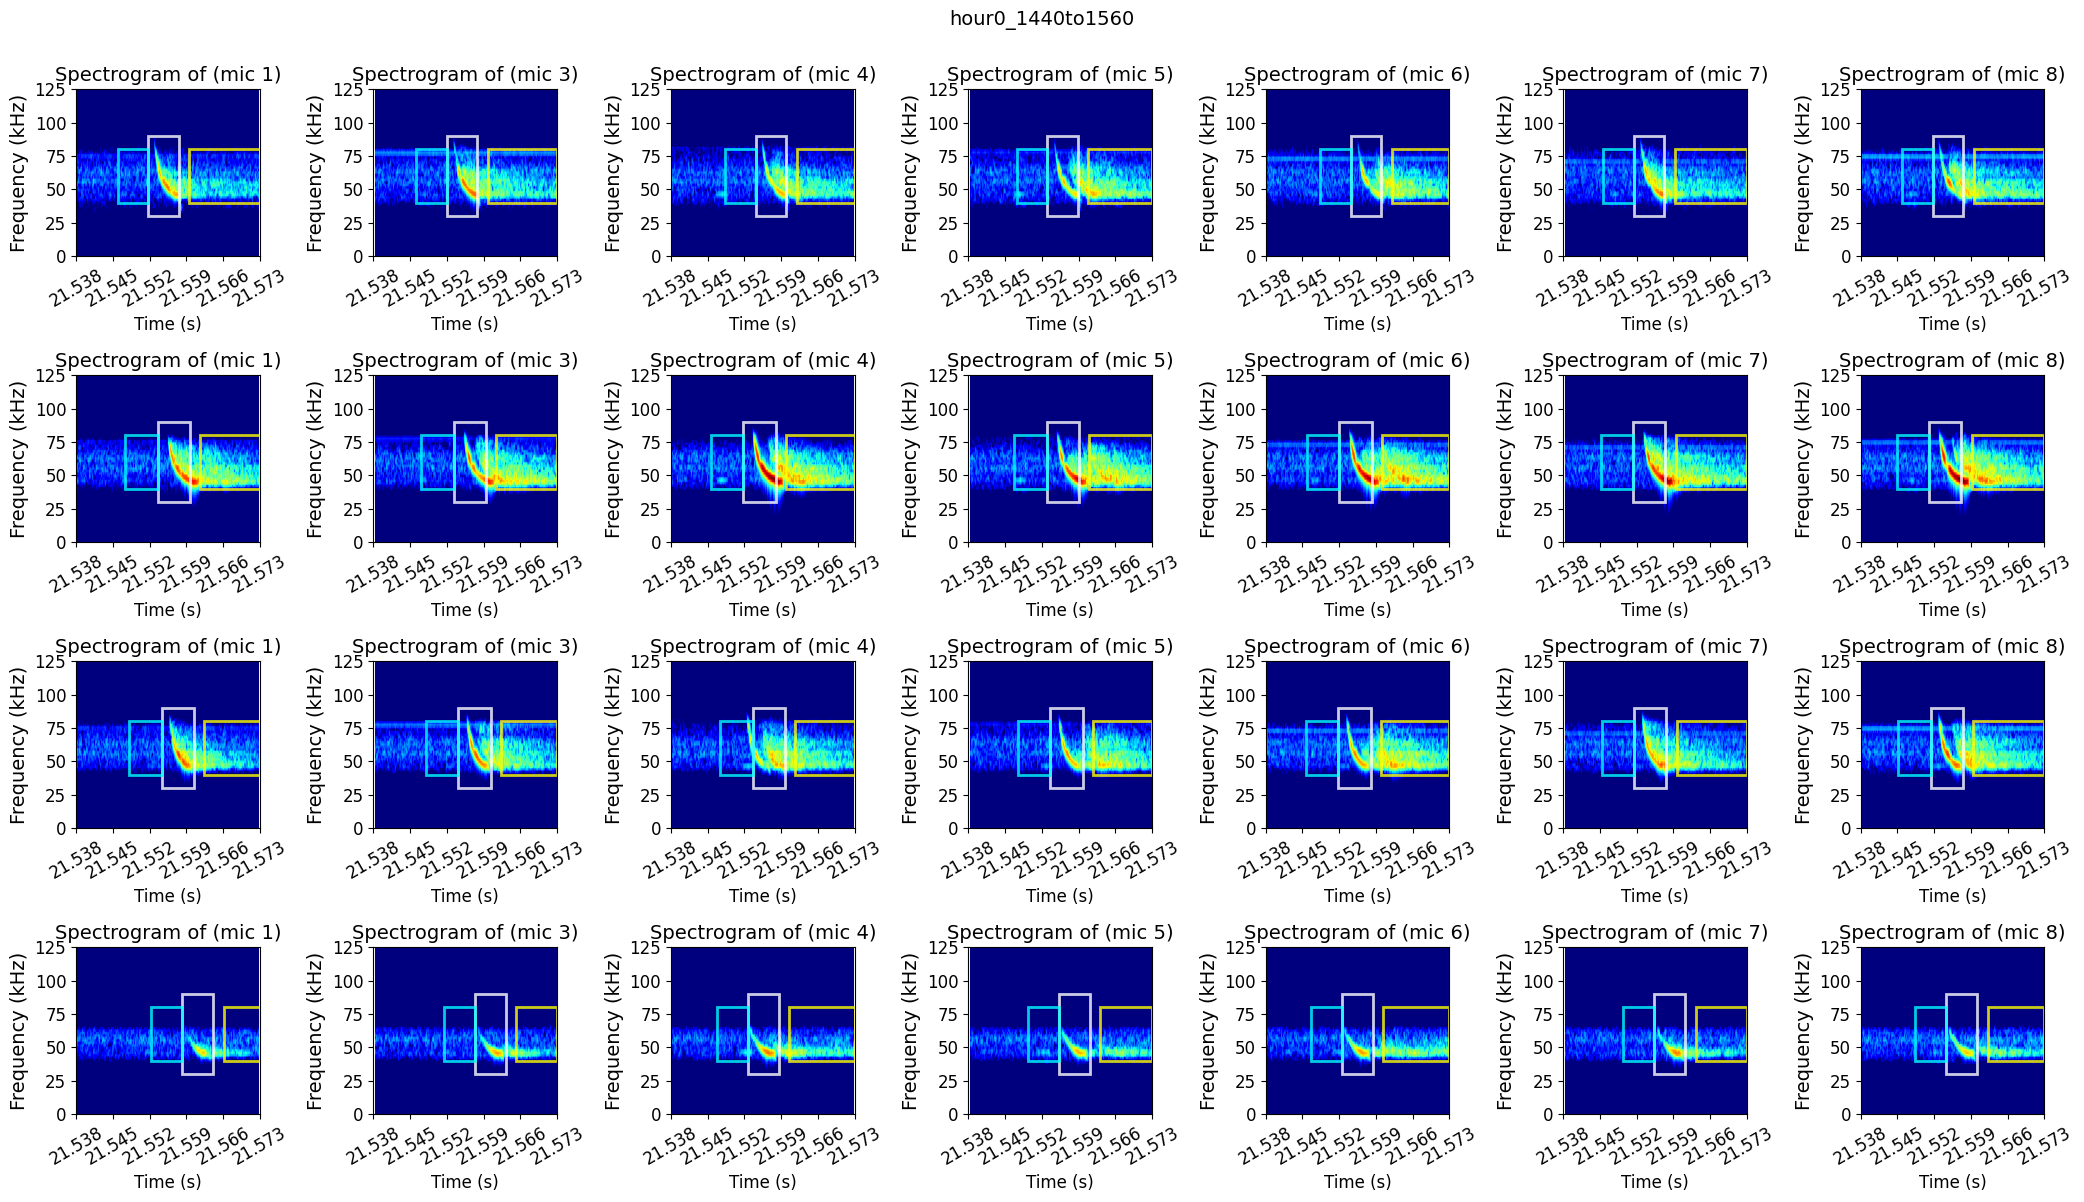

In [182]:
%matplotlib inline

CORR_LENGTH = 0.035
t_delay_wrt_selected_channel = []
channel_num = 0
plt.figure(figsize=(3*num_good_channels, 3*(example_calls.shape[0])))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=14)
for det_num in range(example_calls.shape[0]):
    non_ref_calls_of_det = example_calls[det_num]
    approx_call_dur = example_det_durs[det_num]
    ref_call_of_det = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
    ref_mic_call_only = extract_reference_call_only(ref_call_of_det, approx_call_dur)

    for non_ref_call_i in range(non_ref_calls_of_det.shape[0]):
        signal1 = non_ref_calls_of_det[non_ref_call_i, :int(fs*CORR_LENGTH)]
        signal2 = ref_mic_call_only
        time_delay_in_samples = generalized_cross_correlation_to_find_t_delay(signal1, signal2)
        time_delay_in_seconds = time_delay_in_samples / fs

        t_delay_wrt_selected_channel += [time_delay_in_seconds]
        channel_num+=1

        spec_features = dict()
        spec_features['NFFT'] = 132 # When segments are short, NFFT should also be small (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -80
        spec_features['vmax'] = 0

        plt.subplot((example_calls.shape[0]), num_good_channels, channel_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Spectrogram of (mic {microphones_used[non_ref_call_i]})", fontsize=14)
        plt.specgram(signal1, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

        found_call_dur = int(fs*(approx_call_dur+0.004))
        found_call_start = int(fs*time_delay_in_seconds)
        found_call_end = found_call_start+found_call_dur
        
        ax = plt.gca()
        rect_call = patches.Rectangle((found_call_start/2, (30000)/(fs/2)), found_call_dur/2, (60000)/(fs/2), 
                        linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
        ax.add_patch(rect_call)
        rect_echo = patches.Rectangle(((found_call_end+int(fs*0.002))/2, 40000/(fs/2)), 
                        ((fs*CORR_LENGTH) - (found_call_end+int(fs*0.002)))/2, 40000/(fs/2), 
                        linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect_echo)
        rect_background = patches.Rectangle(((found_call_start-found_call_dur)/2, 40000/(fs/2)), 
                        (found_call_dur)/2, 40000/(fs/2), 
                        linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
        ax.add_patch(rect_background)
        plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        plt.ylabel("Frequency (kHz)", fontsize=14)
        plt.xticks(ticks=np.linspace(0, CORR_LENGTH*(fs/2), 6), 
                   labels=np.round(np.linspace(start, start+CORR_LENGTH, 6, dtype=float), 3), rotation=30)
        plt.xlabel("Time (s)")    

plt.tight_layout()
plt.show()

In [183]:
t_delay_wrt_selected_channel = np.array(t_delay_wrt_selected_channel).reshape((examining_df.shape[0], num_good_channels))
t_delay_8_to_selected_channel = t_delay_wrt_selected_channel[:,-1].reshape((examining_df.shape[0], 1))
time_delay_mics_to_channel8 = (t_delay_wrt_selected_channel - t_delay_8_to_selected_channel)[:,:-1]
d_mics_to_ref = time_delay_mics_to_channel8 * C
d_mics_to_ref

array([[-0.00686 ,  0.08232 ,  0.838292,  0.4459  ,  0.846524, -0.09604 ],
       [ 0.852012,  0.757344,  0.26068 ,  0.639352,  0.341628,  0.086436],
       [ 1.01528 ,  0.971376,  0.766948,  0.773808,  0.172872,  0.04802 ],
       [ 1.348676,  1.01528 , -0.584472,  0.293608, -0.632492,  0.35672 ]])

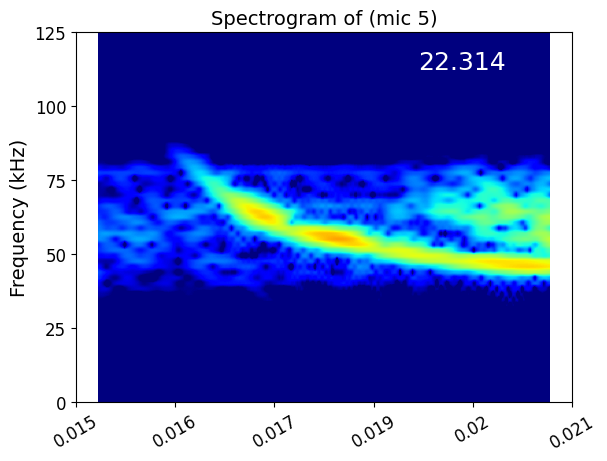

In [184]:
calls = example_calls[0]
approx_call_dur = example_det_durs[0]
best_call_for_det = np.argmax(example_snr_facs[0])
ref_mic_call = calls[best_call_for_det,:]
nonref_mic_calls = calls

found_call_start, found_call_dur = extract_call_starts_for_ref_call(ref_mic_call, approx_call_dur)
found_call_end = (found_call_start+found_call_dur)
ref_mic_call_only = extract_reference_call_only(ref_mic_call, approx_call_dur)

plt.title(f"Spectrogram of (mic {microphones_used[best_call_for_det]})", fontsize=14)
plt.specgram(ref_mic_call_only, NFFT=132, cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, (found_call_end-found_call_start)/2, 6), labels=np.round(np.linspace(found_call_start/fs, found_call_end/fs, 6, dtype=float), 3), rotation=30)
plt.text(x=int(fs*0.004)/2,y=(0.9),s=f'{round(example_snr_facs[0][best_call_for_det], 3)}',color='w',fontsize=18)
plot_xtype = 'float'
plt.ylabel("Frequency (kHz)", fontsize=14)
plt.xlabel("")
plt.show()

In [185]:
z_mag_ref_to_6 = 46.5625
z_mag_ref_to_1 = 35.5
x_mag_ref_to_1 = 17.7
y_mag_ref_to_6 = 21
y_mag_ref_to_1 = 37.5

A_locs_mat = np.array([[-x_mag_ref_to_1, y_mag_ref_to_1, -z_mag_ref_to_1],
                       [-x_mag_ref_to_1, -y_mag_ref_to_1, -z_mag_ref_to_1],
                       [-x_mag_ref_to_1, y_mag_ref_to_1, 0],
                       [-x_mag_ref_to_1, -y_mag_ref_to_1, 0],
                       [-x_mag_ref_to_1, y_mag_ref_to_6, z_mag_ref_to_6],
                       [-x_mag_ref_to_1, -y_mag_ref_to_6, z_mag_ref_to_6],
                       [0, 0, -z_mag_ref_to_1],
                       [0, 0, 0]])

In [186]:
A_locs_mat = A_locs_mat[(microphones_used[:-1]-1),:]
A_locs_mat

array([[-17.7   ,  37.5   , -35.5   ],
       [-17.7   ,  37.5   ,   0.    ],
       [-17.7   , -37.5   ,   0.    ],
       [-17.7   ,  21.    ,  46.5625],
       [-17.7   , -21.    ,  46.5625],
       [  0.    ,   0.    , -35.5   ]])

In [188]:
bucket = np.empty((4, 0))
for i in range(d_mics_to_ref.shape[0]):
    A_mat = np.hstack(((0 - A_locs_mat), d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))))

    xm = A_locs_mat[:,0]
    ym = A_locs_mat[:,1]
    zm = A_locs_mat[:,2]

    wm0 = (d_mics_to_ref[i,:]**2) - (xm**2) - (ym**2) - (zm**2)
    wm0 = wm0.reshape((num_nonref_channels, 1))

    A_pinv = np.linalg.pinv(A_mat)
    source_vec = np.dot(A_pinv, wm0)

    bucket = np.hstack([bucket, source_vec])
bucket

array([[ 9.80475521e+02,  7.24183507e+02, -2.59726362e+02,
         2.44950885e+02],
       [ 4.13988995e+02, -1.92711860e+02,  1.65638872e+01,
        -6.32389341e+02],
       [-1.43260881e+02,  3.65262907e+01, -1.50653251e+01,
         2.60758751e+02],
       [-4.15945339e+04, -2.85771099e+04,  2.83178207e+03,
        -2.95893626e+04]])

In [189]:
fs = 250000
calls_for_tdoa = []
call_snrs_for_tdoa = []
snr_facs_for_tdoa = []
det_durs_for_tdoa = []
set_for_tdoa = subset.copy()
for det_num, det in set_for_tdoa.iterrows():
    approx_call_dur = get_approx_call_dur(det)
    det_durs_for_tdoa += [approx_call_dur]
    for selected_channel in (np.arange(0, num_channels).astype(int)):
        if selected_channel in (microphones_used-1):
            start = det['start_time'] - offset - 0.015
            length = 0.035
            wav_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
            bandpassed_det = extract_bandpassed_detection_from_wavfilepath(wav_file, start, length, det)
            
            found_call_start, found_call_dur = extract_approx_call_start_for_snr_calcs(bandpassed_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            found_call, found_background, found_echo = extract_approx_call_windows_for_snr_calcs(bandpassed_det, 
                                                                                                 found_call_start, 
                                                                                                 found_call_dur)
            snrce = get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = get_snr_from_band_limited_signal(found_call, found_background)
            snreb = get_snr_from_band_limited_signal(found_echo, found_background)

            calls_for_tdoa += [bandpassed_det]
            call_snrs_for_tdoa += [(snrcb + snreb)]
            snr_facs_for_tdoa += [(snrcb + snreb)/snrce]
            
calls_for_tdoa = np.array(calls_for_tdoa).reshape((len(set_for_tdoa), num_good_channels, int(fs*length)))
call_snrs_for_tdoa = np.array(call_snrs_for_tdoa).reshape((len(set_for_tdoa), num_good_channels))
snr_facs_for_tdoa = np.array(snr_facs_for_tdoa).reshape((len(set_for_tdoa), num_good_channels))
det_durs_for_tdoa = np.array(det_durs_for_tdoa)

In [190]:
t_delay_wrt_selected_channel = []
for det_num in range(calls_for_tdoa.shape[0]):
    non_ref_calls_of_det = calls_for_tdoa[det_num]
    approx_call_dur = det_durs_for_tdoa[det_num]
    ref_call_of_det = index_reference_call_based_on_feature_to_maximize(calls_for_tdoa, det_num, snr_facs_for_tdoa)
    ref_mic_call_only = extract_reference_call_only(ref_call_of_det, approx_call_dur)

    for non_ref_call_i in range(non_ref_calls_of_det.shape[0]):
        signal1 = non_ref_calls_of_det[non_ref_call_i,:int(fs*CORR_LENGTH)]
        signal2 = ref_mic_call_only
        time_delay_in_samples = generalized_cross_correlation_to_find_t_delay(signal1, signal2)
        time_delay_in_seconds = time_delay_in_samples / fs
        t_delay_wrt_selected_channel += [time_delay_in_seconds]

In [191]:
t_delay_wrt_selected_channel = np.array(t_delay_wrt_selected_channel).reshape((len(set_for_tdoa), num_good_channels))
t_delay_8_to_selected_channel = t_delay_wrt_selected_channel[:,-1]
time_delay_mics_to_channel8 = (t_delay_wrt_selected_channel - t_delay_wrt_selected_channel[:,-1].reshape((len(set_for_tdoa), 1)))[:,:-1]
d_mics_to_ref = time_delay_mics_to_channel8 * C
d_mics_to_ref.shape

(32, 6)

In [192]:
bucket = np.empty((4, 0))
for i in range(d_mics_to_ref.shape[0]):
    A_mat = np.hstack(((0 - A_locs_mat), d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))))

    xm = A_locs_mat[:,0]
    ym = A_locs_mat[:,1]
    zm = A_locs_mat[:,2]

    wm0 = (d_mics_to_ref[i,:]**2) - (xm**2) - (ym**2) - (zm**2)
    wm0 = wm0.reshape((num_nonref_channels, 1))

    A_pinv = np.linalg.pinv(A_mat)
    source_vec = np.dot(A_pinv, wm0) * (254/10000)

    bucket = np.hstack([bucket, source_vec])

In [193]:
bad_indices = ((bucket[0,:]<-0.6)&((np.abs(bucket[1,:])<(50 * (254/10000)))|(np.abs(bucket[2,:])<50 * (254/10000))))
good_indices = ~bad_indices
cleaned_bucket = bucket[:,good_indices]
good_dets = set_for_tdoa[good_indices]
bad_bucket = bucket[:,bad_indices]
bad_dets = set_for_tdoa[bad_indices]
cleaned_bucket.shape, bad_bucket.shape

((4, 31), (4, 1))

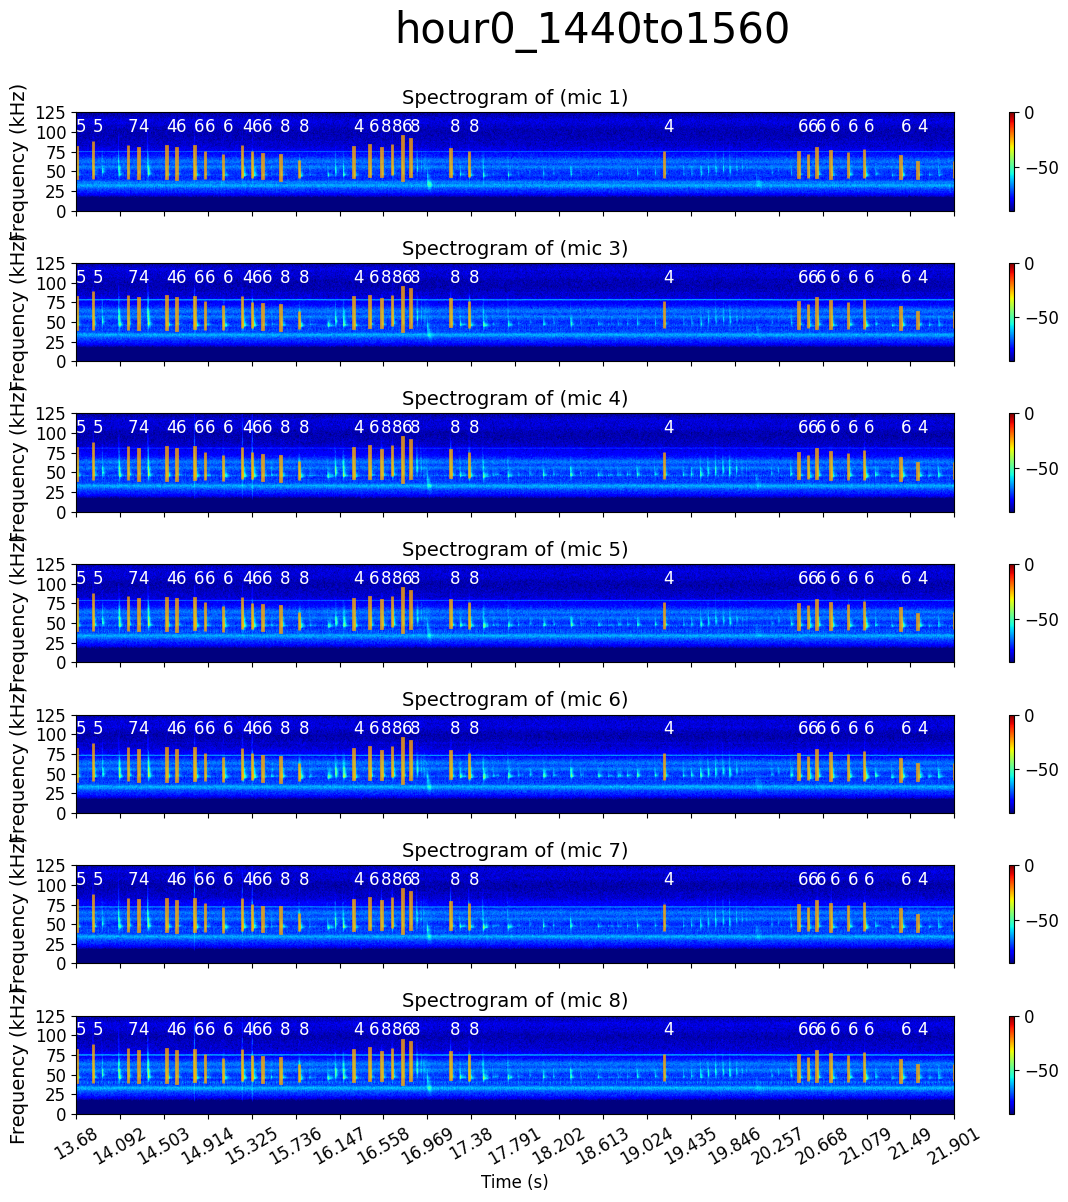

In [194]:
%matplotlib inline

channel_num = 0
plt.figure(figsize=(12, 12))
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=30)
for selected_channel in (np.arange(0, num_channels, 1).astype(int)):
    if selected_channel in (microphones_used-1):
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        
        channel_num+=1
        start = set_for_tdoa.iloc[0]['start_time'] - offset
        length = set_for_tdoa.iloc[-1]['end_time'] - set_for_tdoa.iloc[0]['start_time']
        
        recorded_audio = sf.SoundFile(write_file)
        recorded_audio.seek(int(fs*start))
        audio_seg = recorded_audio.read(int(fs*length))
        highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, 20000)

        vmax = 0
        vmin = -90

        spec_features = dict()
        spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        plt.rcParams.update({'font.size': 12})
        plt.subplot(num_good_channels, 1, channel_num)
        plt.title(f"Spectrogram of (mic {selected_channel+1})", fontsize=14)
        plt.specgram(highpassed_audio_seg+1e-6, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        loudest_call_channels = microphones_used[np.argmax(call_snrs_for_tdoa, axis=1)]
        ax = plt.gca()
        for i, row in set_for_tdoa.iterrows():
            rect = patches.Rectangle(((row['start_time'] - offset - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
            plt.text(x=fs*(row['start_time']-offset-start)/2, y=100e3/(fs/2), s=f'{loudest_call_channels[i]}', color='w')
            ax.add_patch(rect)
        plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        plot_xtype = 'float'
        plt.ylabel("Frequency (kHz)", fontsize=14)
        plt.colorbar()
        plt.xticks(ticks=np.linspace(0, length*(fs/2), 21), labels=['']*21, rotation=30)
        plt.xlabel("")
        
plt.xticks(ticks=np.linspace(0, length*(fs/2), 21), labels=np.round(np.linspace(start, start+length, 21, dtype=plot_xtype), 3), rotation=30)
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

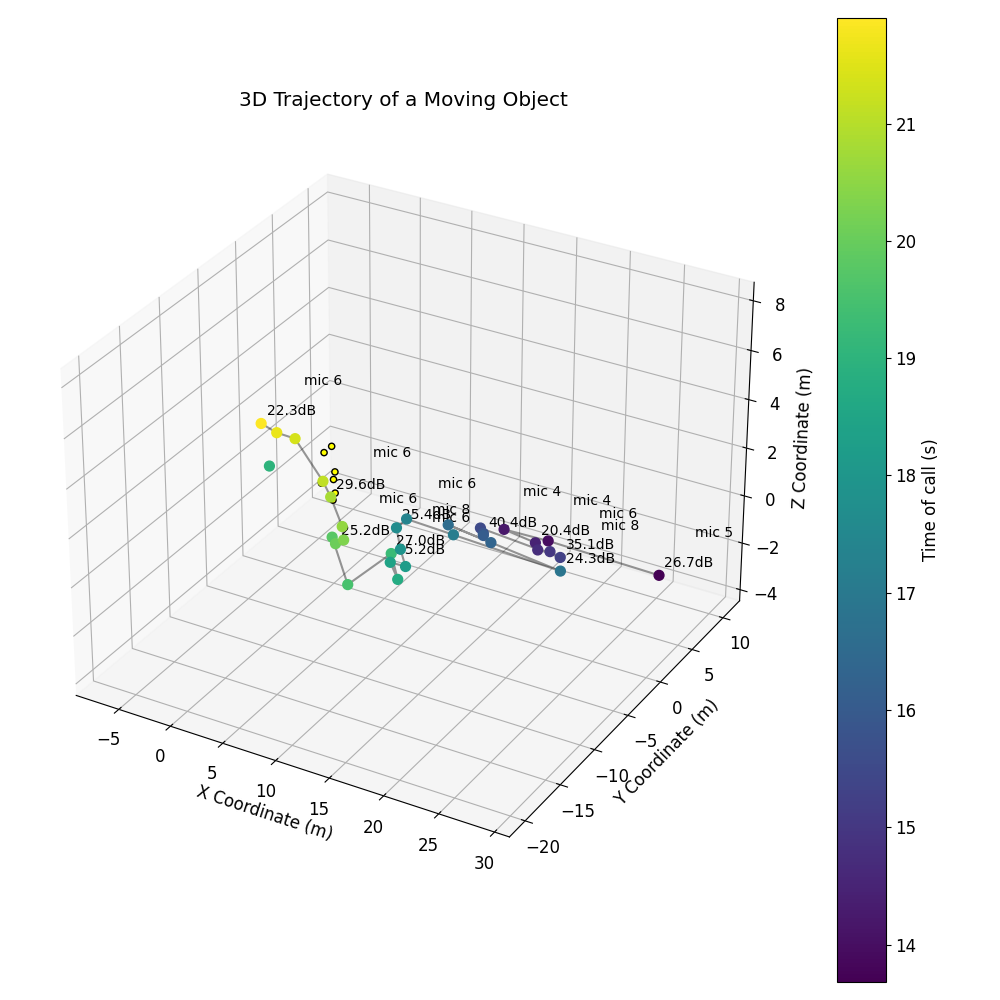

In [195]:
%matplotlib widget

import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable


fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size':12})
ax = fig.add_subplot(projection='3d')

cmap = plt.get_cmap('viridis')
map_vals = (set_for_tdoa['SNR'])
color_vals = np.linspace(start, start+length, map_vals.shape[0])
norm = plt.Normalize(color_vals.min(), color_vals.max())
line_colors = cmap(norm(color_vals))

ax.scatter(bucket[0,:], bucket[1,:], bucket[2,:], color=line_colors, alpha=1, s=50)
ax.plot(cleaned_bucket[0,:], cleaned_bucket[1,:], cleaned_bucket[2,:], color='k', alpha=0.4)
loudest_call_channels = microphones_used[np.argmax(call_snrs_for_tdoa, axis=1)]

for i in np.linspace(0, bucket.shape[1]-1, 11).astype(int):
    scale = 0.3
    t_x, t_y, t_z = bucket[0,i]+scale, bucket[1,i]+scale, bucket[2,i]+scale
    ax.text(x=t_x, y=t_y, z=t_z, s=f'{round(map_vals.iloc[i], 1)}dB', fontsize=10)
    ax.text(x=t_x, y=t_y+5, z=t_z, s=f'mic {round(loudest_call_channels[i], 1)}', fontsize=10)

ax.scatter(xs=A_locs_mat[:,0] * (254/10000), ys=A_locs_mat[:,1] * (254/10000), zs=A_locs_mat[:,2] * (254/10000), facecolor='yellow', edgecolor='k', alpha=1)
ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)

ax.set_xlabel('X Coordinate (m)')
ax.set_ylabel('Y Coordinate (m)')
ax.set_zlabel('Z Coordinate (m)')
ax.set_title('3D Trajectory of a Moving Object')

fig.subplots_adjust(left=0.0, right=1, bottom=0, top=1)
sm = ScalarMappable(cmap=cm.viridis, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Time of call (s)')

plt.tight_layout()
plt.show()

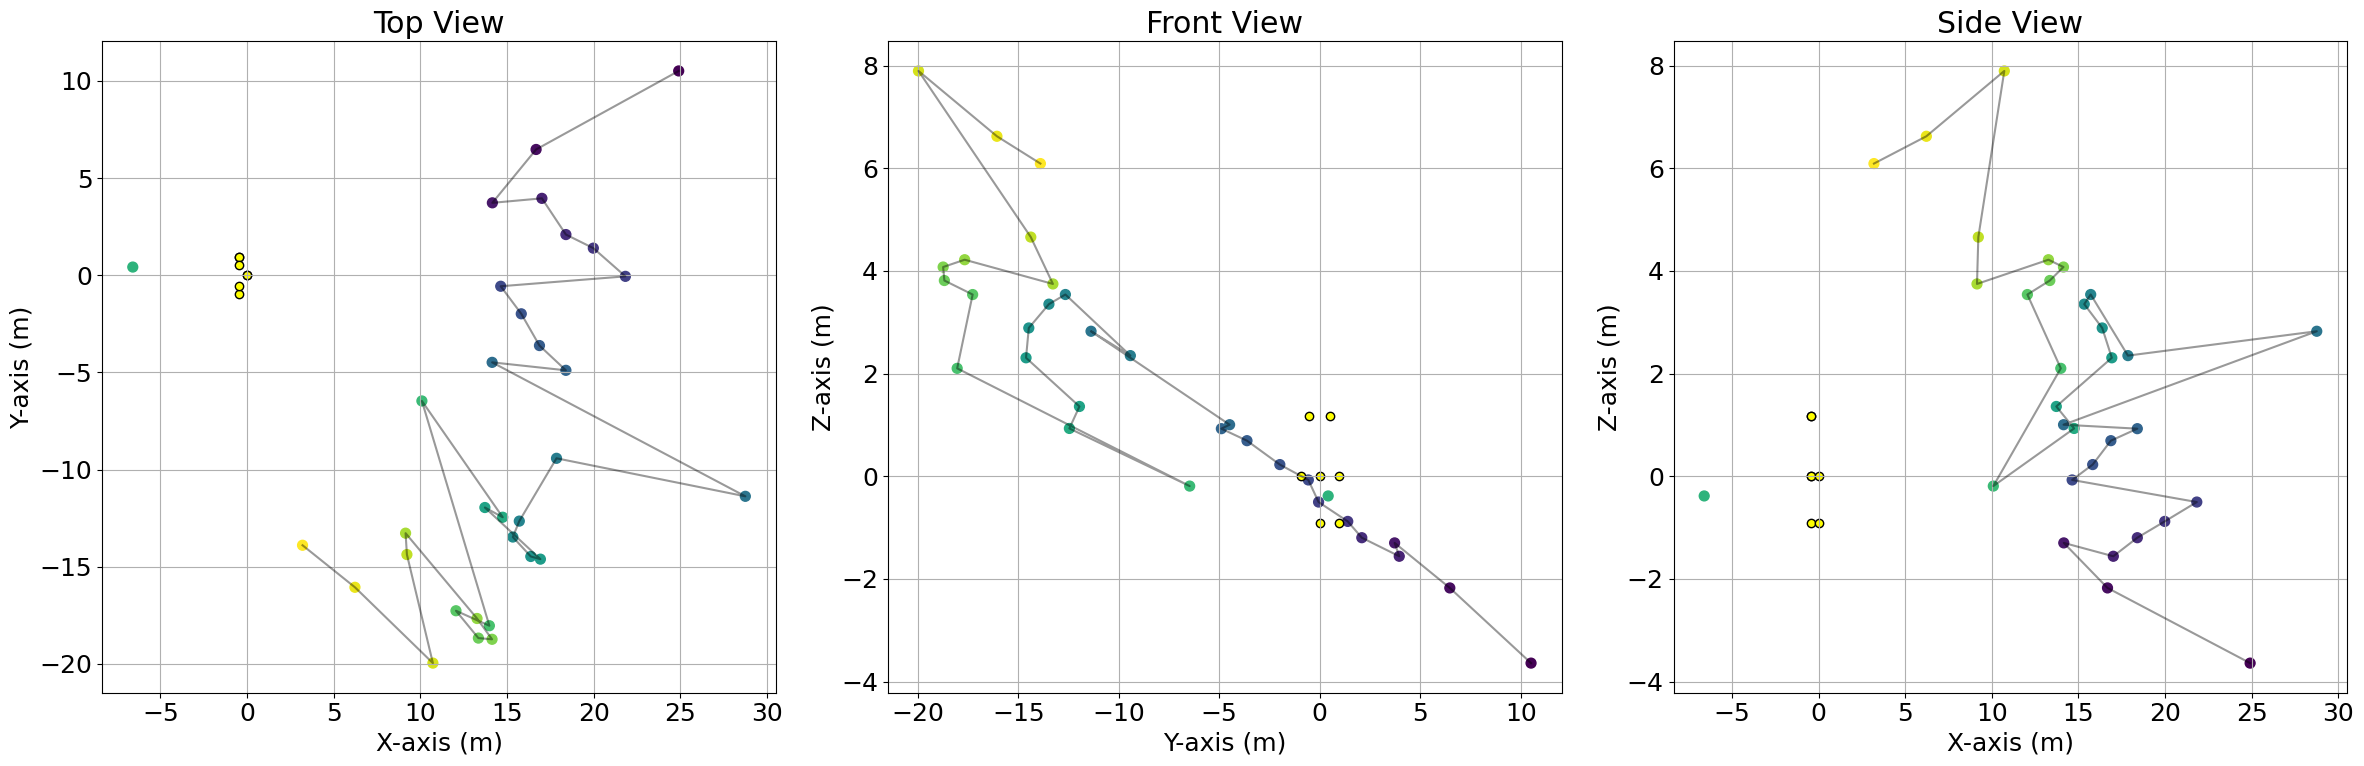

In [196]:
%matplotlib inline

fig = plt.figure(figsize=(24, 8))
plt.rcParams.update({'font.size':18})

plt.subplot(131)
plt.title('Top View')
plt.plot(cleaned_bucket[0,:], cleaned_bucket[1,:], alpha=0.4, color='k')
plt.scatter(bucket[0,:], bucket[1,:], color=line_colors, alpha=1, s=50)
plt.scatter(x=A_locs_mat[:,0] * (254/10000), y=A_locs_mat[:,1] * (254/10000), facecolor='yellow', edgecolor='k')
plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')
plt.grid(which='both')
plt.xlabel('X-axis (m)')
plt.ylabel('Y-axis (m)')

plt.subplot(132)
plt.title('Front View')
plt.plot(cleaned_bucket[1,:], cleaned_bucket[2,:], alpha=0.4, color='k')
plt.scatter(bucket[1,:], bucket[2,:], color=line_colors, alpha=1, s=50)
plt.scatter(x=A_locs_mat[:,1] * (254/10000), y=A_locs_mat[:,2] * (254/10000), facecolor='yellow', edgecolor='k')
plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')
plt.grid(which='both')
plt.xlabel('Y-axis (m)')
plt.ylabel('Z-axis (m)')

plt.subplot(133)
plt.title('Side View')
plt.plot(cleaned_bucket[0,:], cleaned_bucket[2,:], alpha=0.4, color='k')
plt.scatter(bucket[0,:], bucket[2,:], color=line_colors, alpha=1, s=50)
plt.scatter(x=A_locs_mat[:,0] * (254/10000), y=A_locs_mat[:,2] * (254/10000), facecolor='yellow', edgecolor='k')
plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')
plt.grid(which='both')
plt.xlabel('X-axis (m)')
plt.ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

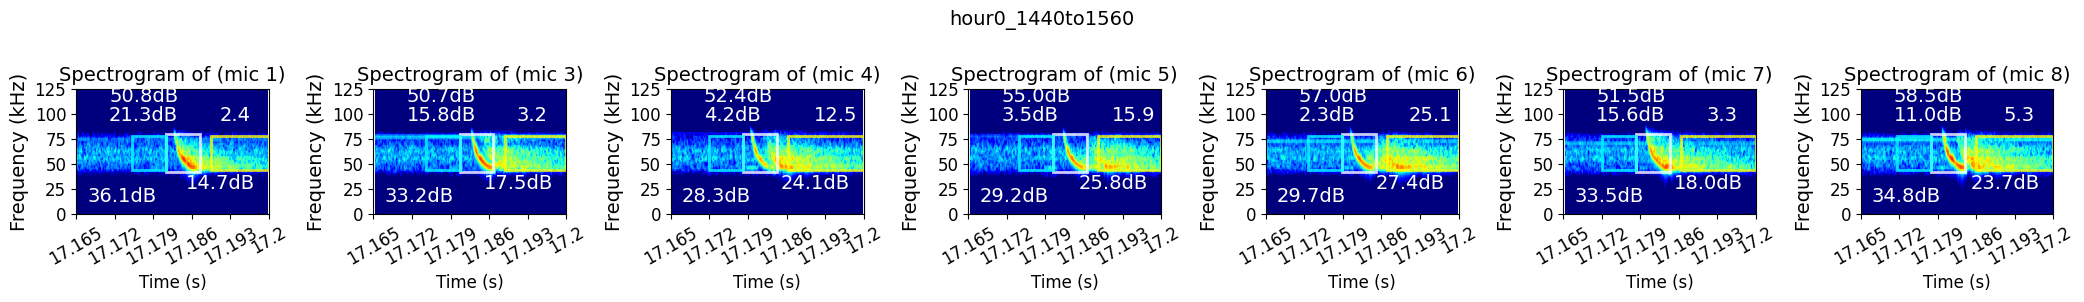

In [197]:
%matplotlib inline

bad_calls = []
bad_call_snrs = []
bad_snr_facs = []
bad_det_durs = []
channel_num = 0
plt.figure(figsize=(3*num_good_channels, 3*len(bad_dets)))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=14)
for i, det in bad_dets.iterrows():
    start = det['start_time'] - offset - 0.015
    length = 0.035
    approx_call_dur = get_approx_call_dur(det)
    bad_det_durs += [approx_call_dur]

    for selected_channel in (np.arange(0, num_channels).astype(int)):
        if selected_channel in (microphones_used-1):
            write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
            channel_num+=1
            
            bandpassed_det = extract_bandpassed_detection_from_wavfilepath(write_file, start, length, det)
            bad_calls += [bandpassed_det]
            found_call_start, found_call_dur = extract_approx_call_start_for_snr_calcs(bandpassed_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            found_call, found_background, found_echo = extract_approx_call_windows_for_snr_calcs(bandpassed_det, 
                                                                                                 found_call_start, 
                                                                                                 found_call_dur)
            snrce = get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = get_snr_from_band_limited_signal(found_call, found_background)
            snreb = get_snr_from_band_limited_signal(found_echo, found_background)
            bad_call_snrs += [snrcb + snreb]
            bad_snr_facs += [snr_quality_metric(snrcb, snreb, snrce)]

            spec_features = dict()
            spec_features['NFFT'] = 132 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
            spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
            spec_features['vmin'] = -80
            spec_features['vmax'] = 0

            plt.subplot(len(bad_dets), num_good_channels, channel_num)
            plt.rcParams.update({'font.size': 12})
            plt.title(f"Spectrogram of (mic {selected_channel+1})", fontsize=14)
            plt.specgram(bandpassed_det+1e-6, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
            plt.text(x=int(fs*0.003),y=0.9,s=f'{round(snrcb+snreb, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.003),y=0.75,s=f'{round(snrce, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.001),y=0.1,s=f'{round(snrcb, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.01),y=0.2,s=f'{round(snreb, 1)}dB',color='w',fontsize=14)
            plt.text(x=int(fs*0.013),y=0.75,s=f'{round((snrcb+snreb)/snrce, 1)}',color='w',fontsize=14)
            ax = plt.gca()
            rect_call = patches.Rectangle((found_call_start/2, (det['low_freq']-2000)/(fs/2)), 
                            found_call_dur/2, ((det['high_freq']-det['low_freq'])+4000)/(fs/2), 
                            linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
            ax.add_patch(rect_call)
            rect_echo = patches.Rectangle(((found_call_end+int(fs*0.002))/2, det['low_freq']/(fs/2)), 
                            ((fs*length) - (found_call_end+int(fs*0.002)))/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
            ax.add_patch(rect_echo)
            rect_background = patches.Rectangle(((found_call_start-found_call_dur)/2, det['low_freq']/(fs/2)), 
                            (found_call_dur)/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                            linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
            ax.add_patch(rect_background)
            plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
            plt.xticks(ticks=np.linspace(0, length*(fs/2), 6), labels=np.round(np.linspace(start, start+length, 6, dtype=float), 3), rotation=30)
            plt.xlabel("Time (s)")    

plt.tight_layout()
plt.show()

In [198]:
bad_calls = np.array(bad_calls).reshape((len(bad_dets), num_good_channels, int(fs*length)))
bad_call_snrs = np.array(bad_call_snrs).reshape((len(bad_dets), num_good_channels))
bad_snr_facs = np.array(bad_snr_facs).reshape((len(bad_dets), num_good_channels))
bad_det_durs = np.array(bad_det_durs).reshape(len(bad_dets))

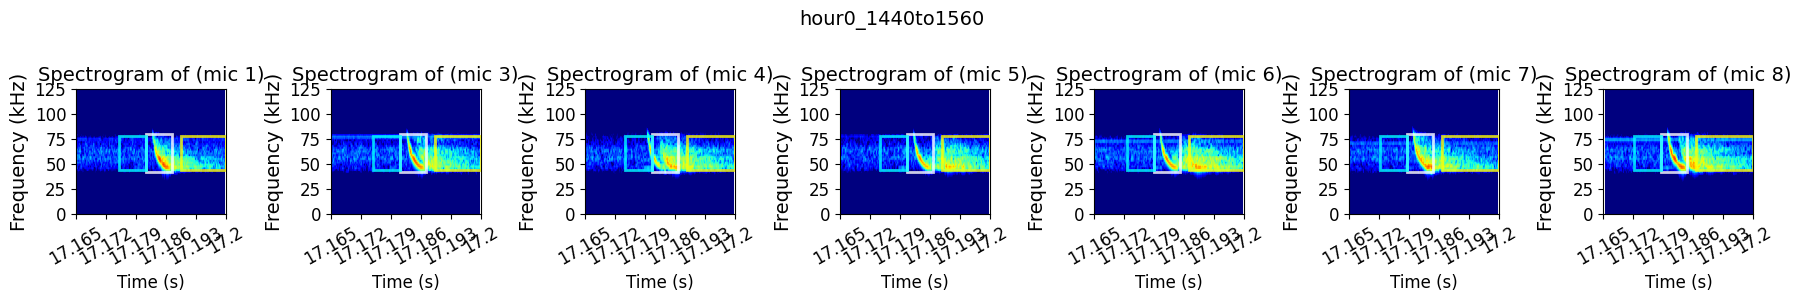

In [199]:
%matplotlib inline

bad_t_delays_wrt_selected_channel = []
channel_num = 0
plt.figure(figsize=(3*6, 3*(bad_calls.shape[0])))
plt.rcParams.update({'font.size': 12})
plt.suptitle(f'hour0_{int(offset)}to{int(offset+duration_in_secs)}', y=1.0, fontsize=14)
for det_num in range(bad_calls.shape[0]):
    non_ref_calls_of_det = bad_calls[det_num]
    mod_det_dur = bad_det_durs[det_num]
    ref_call_of_det = index_reference_call_based_on_feature_to_maximize(bad_calls, det_num, bad_snr_facs)
    ref_mic_call_only = extract_reference_call_only(ref_call_of_det, mod_det_dur)

    for non_ref_call_i in range(non_ref_calls_of_det.shape[0]):
        signal1 = non_ref_calls_of_det[non_ref_call_i, :int(fs*CORR_LENGTH)]
        signal2 = ref_mic_call_only
        time_delay_in_samples = generalized_cross_correlation_to_find_t_delay(signal1, signal2)
        time_delay_in_seconds = time_delay_in_samples / fs
        bad_t_delays_wrt_selected_channel += [time_delay_in_seconds]

        channel_num+=1

        vmax = 0
        vmin = -80
        spec_features = dict()
        spec_features['NFFT'] = 132 # When segments are short, NFFT should also be small (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        plt.subplot(len(bad_dets), num_good_channels, channel_num)
        plt.rcParams.update({'font.size': 12})
        plt.title(f"Spectrogram of (mic {microphones_used[non_ref_call_i]})", fontsize=14)
        plt.specgram(signal1, NFFT=spec_features['NFFT'], cmap='jet', vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        found_call_dur = int(fs*(approx_call_dur+0.004))
        found_call_start = int(fs*time_delay_in_seconds)
        found_call_end = found_call_start+found_call_dur
        ax = plt.gca()
        rect_call = patches.Rectangle((found_call_start/2, (det['low_freq']-2000)/(fs/2)), 
                        found_call_dur/2, ((det['high_freq']-det['low_freq'])+4000)/(fs/2), 
                        linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
        ax.add_patch(rect_call)
        rect_echo = patches.Rectangle(((found_call_end+int(fs*0.002))/2, det['low_freq']/(fs/2)), 
                        ((fs*CORR_LENGTH) - (found_call_end+int(fs*0.002)))/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect_echo)
        rect_background = patches.Rectangle(((found_call_start-found_call_dur)/2, det['low_freq']/(fs/2)), 
                        (found_call_dur)/2, (det['high_freq'] - det['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
        ax.add_patch(rect_background)
        plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
        plt.ylabel("Frequency (kHz)", fontsize=14)
        plt.xticks(ticks=np.linspace(0, CORR_LENGTH*(fs/2), 6), 
                   labels=np.round(np.linspace(start, start+CORR_LENGTH, 6, dtype=float), 3), rotation=30)
        plt.xlabel("Time (s)")    

plt.tight_layout()
plt.show()

In [200]:
bad_t_delays_wrt_selected_channel = np.array(bad_t_delays_wrt_selected_channel).reshape((len(bad_dets), num_good_channels))
bad_t_delays_wrt_selected_channel

array([[0.016296, 0.016168, 0.015572, 0.015592, 0.01384 , 0.013476,
        0.013336]])

In [201]:
bad_t_delay_8_to_selected_channel = bad_t_delays_wrt_selected_channel[:,-1]
bad_time_delay_mics_to_channel8 = (bad_t_delays_wrt_selected_channel - bad_t_delay_8_to_selected_channel.reshape((len(bad_dets), 1)))[:,:-1]
bad_d_mics_to_ref = bad_time_delay_mics_to_channel8 * C
bad_d_mics_to_ref

array([[1.01528 , 0.971376, 0.766948, 0.773808, 0.172872, 0.04802 ]])

In [202]:
bad_bucket_examined = np.empty((4, 0))
for i in range(bad_d_mics_to_ref.shape[0]):
    A_mat = np.hstack(((0 - A_locs_mat[:]), bad_d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))))

    xm = A_locs_mat[:,0]
    ym = A_locs_mat[:,1]
    zm = A_locs_mat[:,2]

    wm0 = (bad_d_mics_to_ref[i,:]**2) - (xm**2) - (ym**2) - (zm**2)
    wm0 = wm0.reshape((num_nonref_channels, 1))

    A_pinv = np.linalg.pinv(A_mat)
    source_vec = np.dot(A_pinv, wm0)*(254/10000)

    bad_bucket_examined = np.hstack([bad_bucket_examined, source_vec])
bad_bucket_examined

array([[-6.5970496 ],
       [ 0.42072274],
       [-0.38265926],
       [71.92726456]])

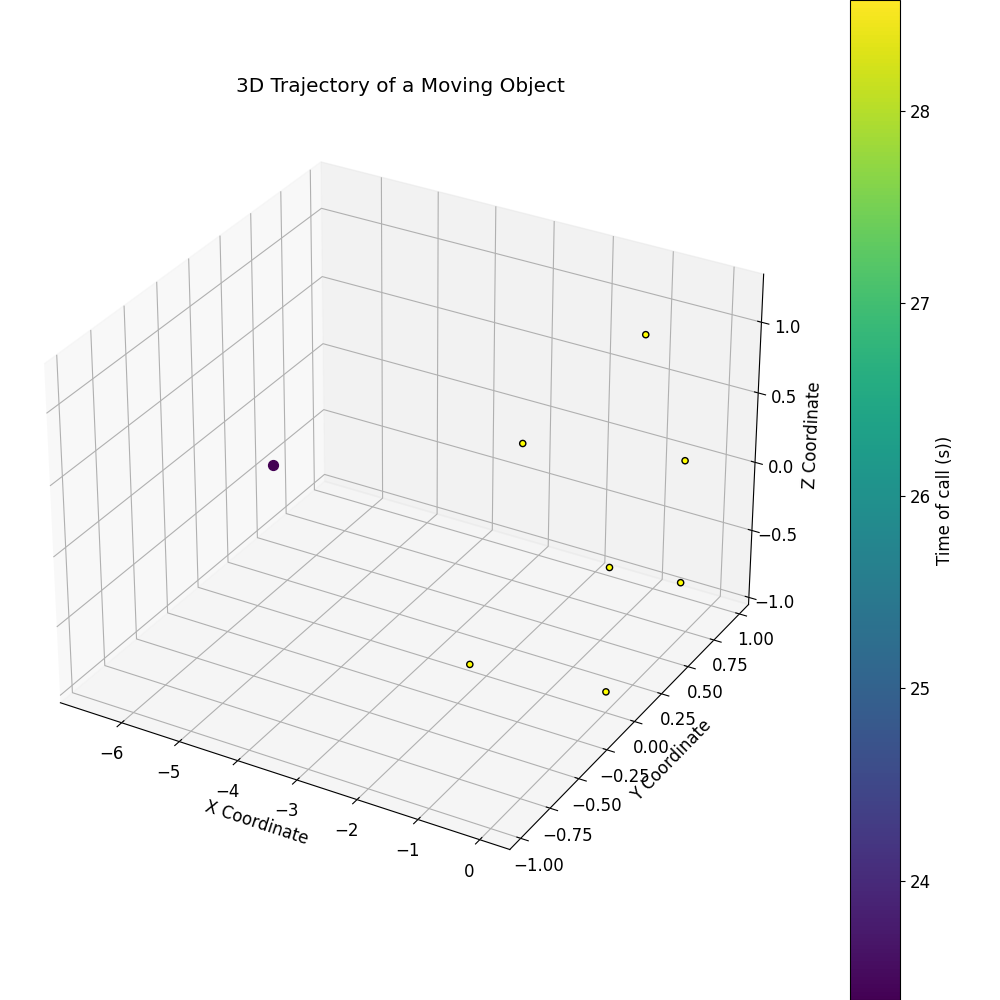

In [203]:
%matplotlib widget

import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable


fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size':12})
ax = fig.add_subplot(projection='3d')

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(bad_dets['SNR'].min(), bad_dets['SNR'].max())
line_colors = cmap(norm(bad_dets['SNR']))

ax.scatter(bad_bucket_examined[0,:], bad_bucket_examined[1,:], bad_bucket_examined[2,:], color=line_colors, alpha=1, s=50)
ax.plot(bad_bucket_examined[0,:], bad_bucket_examined[1,:], bad_bucket_examined[2,:], color='k', alpha=0.4)

ax.scatter(xs=A_locs_mat[:,0]*(254/10000), ys=A_locs_mat[:,1]*(254/10000), zs=A_locs_mat[:,2]*(254/10000), facecolor='yellow', edgecolor='k', alpha=1)
ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Trajectory of a Moving Object')

fig.subplots_adjust(left=0.0, right=1, bottom=0, top=1)
sm = ScalarMappable(cmap=cm.viridis, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Time of call (s))')
plt.show()